#### imports

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle as pk
import mlflow
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import root_mean_squared_error

!python -V

Python 3.12.7


#### configs

In [2]:
# configs
# set the tracking uri to the local sqlite db
mlflow.set_tracking_uri("sqlite:///mlflow.db")
# set the experiment name
mlflow.set_experiment("NYC-taxi-duration-prediction")

2025/04/04 16:18:12 INFO mlflow.tracking.fluent: Experiment with name 'NYC-taxi-duration-prediction' does not exist. Creating a new experiment.


<Experiment: artifact_location='/home/yezergm/mlops-zoomcamp/02-experiment-tracking/mlruns/1', creation_time=1743783492519, experiment_id='1', last_update_time=1743783492519, lifecycle_stage='active', name='NYC-taxi-duration-prediction', tags={}>

#### dev

In [3]:
df = pd.read_parquet('./data/green_tripdata_2024-12.parquet')
df.passenger_count.value_counts()

passenger_count
1.0    43175
2.0     5129
5.0     1221
6.0      918
0.0      747
3.0      507
4.0      303
8.0        6
9.0        4
7.0        3
Name: count, dtype: int64

#### functions

In [4]:
def read_dataframe(filename):
    df = pd.read_parquet(filename)

    df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
    df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)

    df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
    df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

    df = df[(df.duration >= 1) & (df.duration <= 60)]

    categorical = ['PULocationID', 'DOLocationID']
    df[categorical] = df[categorical].astype(str)
    
    return df


#### training

In [6]:
df_train = read_dataframe('./data/green_tripdata_2021-01.parquet')
df_val = read_dataframe('./data/green_tripdata_2021-02.parquet')
print(len(df_train), len(df_val))

df_train['PU_DO'] = df_train['PULocationID'] + '_' + df_train['DOLocationID']
df_val['PU_DO'] = df_val['PULocationID'] + '_' + df_val['DOLocationID']

cat = ['PU_DO']
num = ['trip_distance']
target = 'duration'

dv = DictVectorizer()
train_dicts = df_train[cat + num].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)
y_train = df_train[target].values
val_dicts = df_val[cat + num].to_dict(orient='records')
X_val = dv.transform(val_dicts)
y_val = df_val[target].values

model = LinearRegression()
model.fit(X_train, y_train)

73908 61921


LinearRegression()

#### plots

RMSE train: 5.6995641181994925
RMSE val: 7.758715200888857


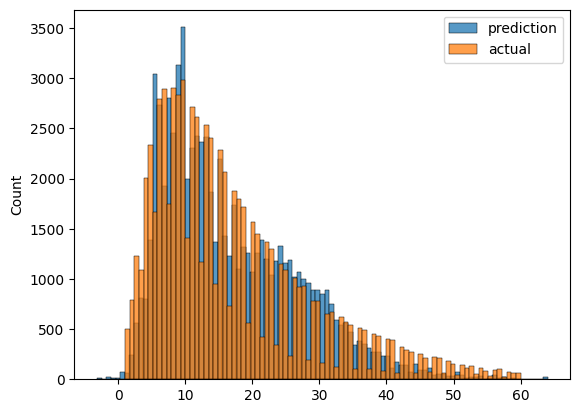

In [7]:
y_pred_train = model.predict(X_train)
print(f'RMSE train: {root_mean_squared_error(y_train, y_pred_train)}')
y_pred_val = model.predict(X_val)
print(f'RMSE val: {root_mean_squared_error(y_val, y_pred_val)}')

sns.histplot(y_pred_train, label='prediction')
sns.histplot(y_train, label='actual')
plt.legend()
plt.show()

#### saving the model

In [21]:
with open('./models/lin_reg.bin', 'wb') as f_out:
    pk.dump((model, dv), f_out)


##### Lasso

In [12]:
with mlflow.start_run():

    alpha = 0.01
    mlflow.set_tag("developer", "yezer")
    mlflow.log_param("train-data-path", "./data/green_tripdata_2021-01.parquet")
    mlflow.log_param("valid-data-path", "./data/green_tripdata_2021-02.parquet")
    mlflow.log_param("alpha", alpha)
    
    model = Lasso(alpha=alpha)
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    print(f'RMSE train: {root_mean_squared_error(y_train, y_pred_train)}')
    y_pred_val = model.predict(X_val)
    print(f'RMSE val: {root_mean_squared_error(y_val, y_pred_val)}')
    mlflow.log_metric("rmse-train", root_mean_squared_error(y_train, y_pred_train))
    mlflow.log_metric("rmse-val", root_mean_squared_error(y_val, y_pred_val))
    

RMSE train: 10.550479040582232
RMSE val: 11.167275941179728
